# PCA:(Principal Component Analysis)
PCA is a dimensionality reduction technique used in data analysis and machine learning.

It helps simplify large datasets by reducing the number of variables (features) while keeping most of the important information.

## How PCA Works (Step by Step)
1> Standardize the data

Features may have different scales (e.g., height in cm vs. weight in kg).

Standardization ensures fair comparison.

2> Compute the covariance matrix: This shows how features vary together.

Positive covariance → both increase/decrease together.

Negative covariance → one increases while the other decreases.

Zero covariance → no relationship

Covariance in PCA helps us understand how features vary together. PCA uses the covariance matrix to find new axes (principal components) that capture the maximum variance in the data. By analyzing covariance, PCA reduces redundancy and compresses correlated features into fewer dimensions while preserving the most important information.


3> Find eigenvalues and eigenvectors

Eigenvectors = new directions (principal components).

Eigenvalues = importance (variance explained) of each direction.

4> Rank components

The first principal component captures the most variance.

The second captures the next most, and so on.

5> Transform the data

Project the original data onto these new axes.

You now have fewer dimensions but still capture most of the variation.

## Goal:
Simplify data, reduce noise, improve efficiency, and aid visualization.

## When to use:

High-dimensional datasets

Multicollinearity (features highly correlated)

Visualization of complex data in 2D/3D

## Limitations:

PCA is linear (may not capture nonlinear relationships).

Components are not always easy to interpret.

Scaling matters—must standardize data first.

# Import Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [12]:
#Load a Dataset
iris = load_iris()
# print(iris.data)

x = iris.data
y = iris.target

In [14]:
df = pd.DataFrame(x,columns=iris.feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [16]:
#Standardize the Data
scalar = StandardScaler()
x_scaled = scalar.fit_transform(x)

#fit → learns the parameters (mean and standard deviation) from the training data only.

#transform → applies those parameters to scale the training data.

#fit_transform → does both in one step.
#This ensures the model learns scaling based only on training data, not test data (to avoid data leakage).

we do not call fit_transform() again on test data.

Instead, we only use transform().

Why? Because we must apply the same scaling parameters learned from training data to the test data.

👉If we fit again on test data, we’d be cheating — the model would "peek" at test data statistics.

In [19]:
#Apply PCA : Keep all components first
pca =PCA(n_components=4)
X_pca = pca.fit_transform(x_scaled)

In [20]:
# Explained variance ratio:explained_variance_ratio_ tells us how much information (variance) each principal component captures.
# Usually, the first 2 components capture most of the variance

print("Explained variance ratio:", pca.explained_variance_ratio_)

Explained variance ratio: [0.72962445 0.22850762 0.03668922 0.00517871]


In [22]:
#Reduce Dimensions (e.g., to 2D)
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(x_scaled)

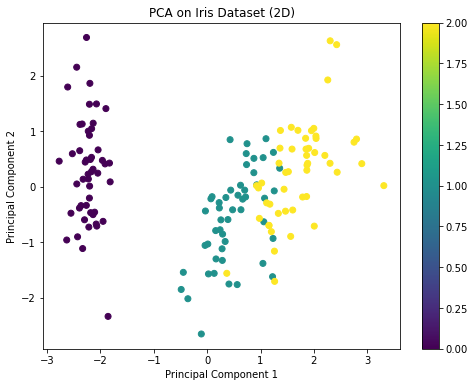

In [23]:
# Plot the transformed data
plt.figure(figsize=(8,6))
plt.scatter(X_pca_2d[:,0], X_pca_2d[:,1], c=y, cmap='viridis')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA on Iris Dataset (2D)')
plt.colorbar()
plt.show()

PCA(n_components=2) → reduce dataset to 2 dimensions.

X_pca_2d → transformed dataset with only 2 principal components.

plt.scatter → plots the data points in 2D space.

c=y → colors points by species (so you can see separation).

cmap='viridis' → sets the color scheme.

Labels and title → make the plot readable.

plt.colorbar() → shows which color corresponds to which species.

👉 This plot shows how PCA compresses 4D data into 2D while still separating species fairly well.